# Exercise: Predict T-Shirt Size (Multiclass Classification)

**Scenario:** You run an online clothing store, and your #1 headache is **returns** — people order the wrong size, ship it back, and everyone's sad. 😩 So you collect each customer's **height** and **weight** and want to recommend the right T-shirt size automatically.

Sizes come in **three** flavours: **S**, **M**, **L**. Since each customer gets **exactly one** of three labels, this is a **multiclass classification** problem — perfect for `LogisticRegression`.

Columns in `tshirt_sizes.csv`:
- `height_cm` — height in centimetres
- `weight_kg` — weight in kilograms
- `size` — the T-shirt size they actually wear (`S`, `M`, or `L`)

---
Fill in the empty code cells below — each has hints in the comments. When you're done, check yourself against `exercise_solution_multiclass.ipynb`. 🧑‍💻

## Step 1 — Load the data

Read `tshirt_sizes.csv` and show the first few rows.

In [1]:
# import pandas
# read 'tshirt_sizes.csv' into a DataFrame called df
# show df.head()
import pandas as pd
df = pd.read_csv('tshirt_sizes.csv')
df.head(5)

,height_cm,weight_kg,size
0,159.8,62.8,S
1,164.6,50.5,S
2,179.2,65.7,L
3,156.8,54.3,S
4,173.6,62.3,M


In [2]:
# count how many customers wear each size with df['size'].value_counts()
df['size'].value_counts()

size
S    45
L    45
M    45
Name: count, dtype: int64

## Step 2 — Look at the data first

Make a scatter plot of `height_cm` (x) vs `weight_kg` (y), coloured by `size`. Add axis labels, a title, and a legend.

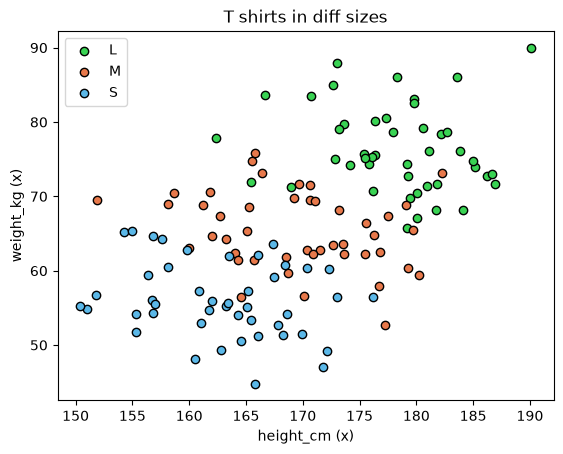

In [3]:
# import matplotlib.pyplot as plt
# tip: loop over df.groupby('size') and scatter each group in a different colour
#      so the legend shows S, M, L
import matplotlib.pyplot as plt

colors = {'S': '#5BB8E8', 'L': '#39D353', 'M': '#E8794B'}
for name, group in df.groupby('size'):
    plt.scatter(group.height_cm, group.weight_kg,
                color=colors[name], edgecolor='k', label=name)
plt.xlabel("height_cm (x)")
plt.ylabel("weight_kg (x)")
plt.title("T shirts in diff sizes")
plt.legend()
plt.show()

## Step 3 — Features (X) and target (y)

`X` = the two measurement columns, `y` = the `size` column.

In [4]:
# X = df[['height_cm', 'weight_kg']]
# y = df['size']
# print X.shape and the unique classes in y
X = df[['height_cm', 'weight_kg']]
y = df['size']
X.shape,y.unique()

((135, 2),
 <StringArray>
 ['S', 'L', 'M']
 Length: 3, dtype: str)

## Step 4 — Train / test split

Hold back 20% for testing (`random_state=42`).

In [7]:
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# print how many training and testing rows you have
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape,y_test.shape

((108, 2), (27,))

## Step 5 — Train the multiclass model

Use `LogisticRegression` (pass `max_iter=200` so it has room to converge).

In [8]:
# from sklearn.linear_model import LogisticRegression
# create the model, fit it on X_train / y_train
# print model.classes_ to see the three sizes it learned
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200)
model.fit(X_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

## Step 6 — Predict on the test set

Compare predictions against the true sizes.

In [10]:
# y_pred = model.predict(X_test)
# build a DataFrame with columns 'actual' and 'predicted' and show the first few rows
import pandas as pd
y_pred = model.predict(X_test)

compare = pd.DataFrame({'actual':y_test.values,'predicted':y_pred})
compare.head(10)

,actual,predicted
0,M,M
1,S,S
2,M,M
3,S,M
4,M,M
5,S,S
6,S,S
7,M,M
8,S,S
9,S,M


## Step 7 — Accuracy

In [11]:
# use model.score(X_test, y_test) and print the accuracy
model.score(X_test, y_test)

0.8888888888888888

## Step 8 — Confusion matrix

Build a 3×3 confusion matrix (use `labels=['S','M','L']` so it reads in order) and plot it.

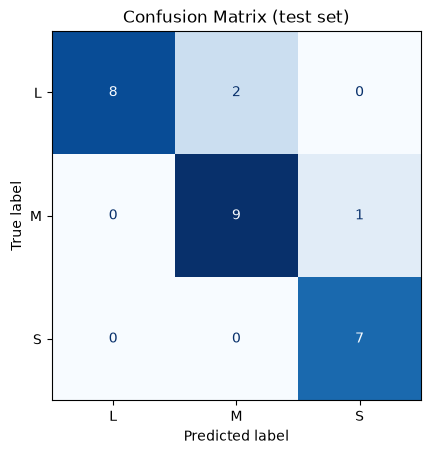

In [13]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# size_order = ['S', 'M', 'L']
# cm = confusion_matrix(y_test, y_pred, labels=size_order)
# then ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=size_order).plot(...)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
size_order = ['S', 'M', 'L']
cm = confusion_matrix(y_test, y_pred, labels=size_order)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix (test set)')
plt.show()

**Question:** Where do the mistakes land — between neighbouring sizes (S↔M, M↔L), or does the model ever confuse an **S** with an **L**? Why do you think that is?

_Your answer here..._

## Step 9 — Classification report

Print precision / recall / f1 per size (again pass `labels=['S','M','L']`).

In [14]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, labels=['S', 'M', 'L']))


              precision    recall  f1-score   support

           S       1.00      0.80      0.89        10
           M       0.82      0.90      0.86        10
           L       0.88      1.00      0.93         7

    accuracy                           0.89        27
   macro avg       0.90      0.90      0.89        27
weighted avg       0.90      0.89      0.89        27



## Step 10 — Recommend a size for a new customer

A new shopper is **178 cm** and **74 kg**. Predict their size.

In [17]:
# build a one-row DataFrame with height_cm=178, weight_kg=74
# call model.predict(...) and print the recommended size
new_order = pd.DataFrame({'height_cm':[178],'weight_kg':[74]})
model.predict(new_order)[0]

'L'

**Bonus challenge:** Try changing `random_state` in the split, or predicting for a customer right on a size boundary (e.g. 170 cm, 62 kg). Does the answer flip? 🤔